In [1]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import os

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

In [12]:
num_shots = 10
# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

ds = myQML.QuantumDatasetGenerator(100,250, myQML.X)
ds.generate_density_matrices_vec()
ds.compute_expectation_values_vec()

rho_train_full, y_train_full = ds.get_training_dataset()
rho_test, y_test = ds.get_test_dataset()

V = myQML.random_isometry(d_in, d_in * d_res)
qelm_1 = myQML.QuantumExtremeLearningMachine(
    isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
    keep_subsystem=1, num_shots=num_shots)

qelm_2 = myQML.QuantumExtremeLearningMachine(
    isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
    keep_subsystem=1, num_shots=num_shots)

qelm_1.fit_vec_2(rho_train_full, y_train_full)
print(qelm_1.predict_vec_2(rho_test).shape)
print(qelm_1.W.shape)
print(qelm_1.get_features_vec_2(rho_train_full).shape)


(250,)
(64,)
(64, 100)


In [14]:
N_train_list = [2,3,4,5,6,30,40,64,80]  
N_test = 250
num_realizations = 100
num_shots = 100
filename = "qelm_test.json"

# --- LOAD PREVIOUS DATA IF IT EXISTS ---
if os.path.exists(filename):
    print(f"Found existing file '{filename}'. Loading previous data...")
    with open(filename, 'r') as f:
        saved_data = json.load(f)
else:
    print("No previous data found. Starting fresh.")
    saved_data = {'QELM_1': {}, 'QELM_2': {}}

# Filter N_train_list to ONLY calculate values we haven't done yet
# (JSON saves dictionary keys as strings, so we check str(N))
N_train_to_run = [N for N in N_train_list if str(N) not in saved_data['QELM_1']]

if not N_train_to_run:
    print("All N_train values in the list have already been simulated. Exiting.")
    exit()

print(f"Simulating for N_train = {N_train_to_run}")

N_max = max(N_train_to_run)

# QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res) 
num_povm_elements = len(povm)

# Temporary dictionary for the CURRENT run
mse_runs = {
    'QELM_1': {N: [] for N in N_train_to_run},
    'QELM_2': {N: [] for N in N_train_to_run},
}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()


# INVERTED LOOP
for r in range(num_realizations):
    if (r + 1) % 10 == 0:
        print(f"Processing Realization {r + 1}/{num_realizations}...")
        
    ds = myQML.QuantumDatasetGenerator(N_max, N_test, myQML.X)
    ds.generate_density_matrices_vec()
    ds.compute_expectation_values_vec()

    rho_train_full, y_train_full = ds.get_training_dataset()
    rho_test, y_test = ds.get_test_dataset()

    #putting V here, we are assuming that for each realization the input state of
    #the reservoir is the same, and that the only thing that changes is the training/test states
    V = myQML.random_isometry(d_in, d_in * d_res)
    qelm = myQML.QuantumExtremeLearningMachine(
        isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, num_shots=num_shots
    )

    qelm2 = myQML.QuantumExtremeLearningMachine(
        isometry=V, povm=povm, bipartite_dims=(d_in, d_res), 
        keep_subsystem=1, num_shots=num_shots
    )

    for N_train in sorted(N_train_to_run, reverse=True):
        rho_train_sub = rho_train_full[:N_train]
        y_train_sub = y_train_full[:N_train]

        #QELM
        qelm.fit_vec(rho_train_sub, y_train_sub)
        qelm2.fit_vec_2(rho_train_sub, y_train_sub)
        mse_runs['QELM_1'][N_train].append(float(np.mean((qelm.predict_vec(rho_test) - y_test)**2)))
        mse_runs['QELM_2'][N_train].append(float(np.mean((qelm2.predict_vec(rho_test) - y_test)**2)))


# --- MERGE AND SAVE DATA ---
for model in mse_runs.keys():
    for N_train, mse_list in mse_runs[model].items():
        # JSON requires dictionary keys to be strings
        saved_data[model][str(N_train)] = mse_list

with open(filename, 'w') as f:
    json.dump(saved_data, f, indent=4)

print("="*70)
print(f"Experiment finished and data appended to '{filename}' in {(time.time() - total_time)/60:.1f} minutes.")

No previous data found. Starting fresh.
Simulating for N_train = [2, 3, 4, 5, 6, 30, 40, 64, 80]
-------- (Shots = 100, Realizations = 100) --------


Processing Realization 10/100...
Processing Realization 20/100...
Processing Realization 30/100...
Processing Realization 40/100...
Processing Realization 50/100...
Processing Realization 60/100...
Processing Realization 70/100...
Processing Realization 80/100...
Processing Realization 90/100...
Processing Realization 100/100...
Experiment finished and data appended to 'qelm_test.json' in 15.7 minutes.


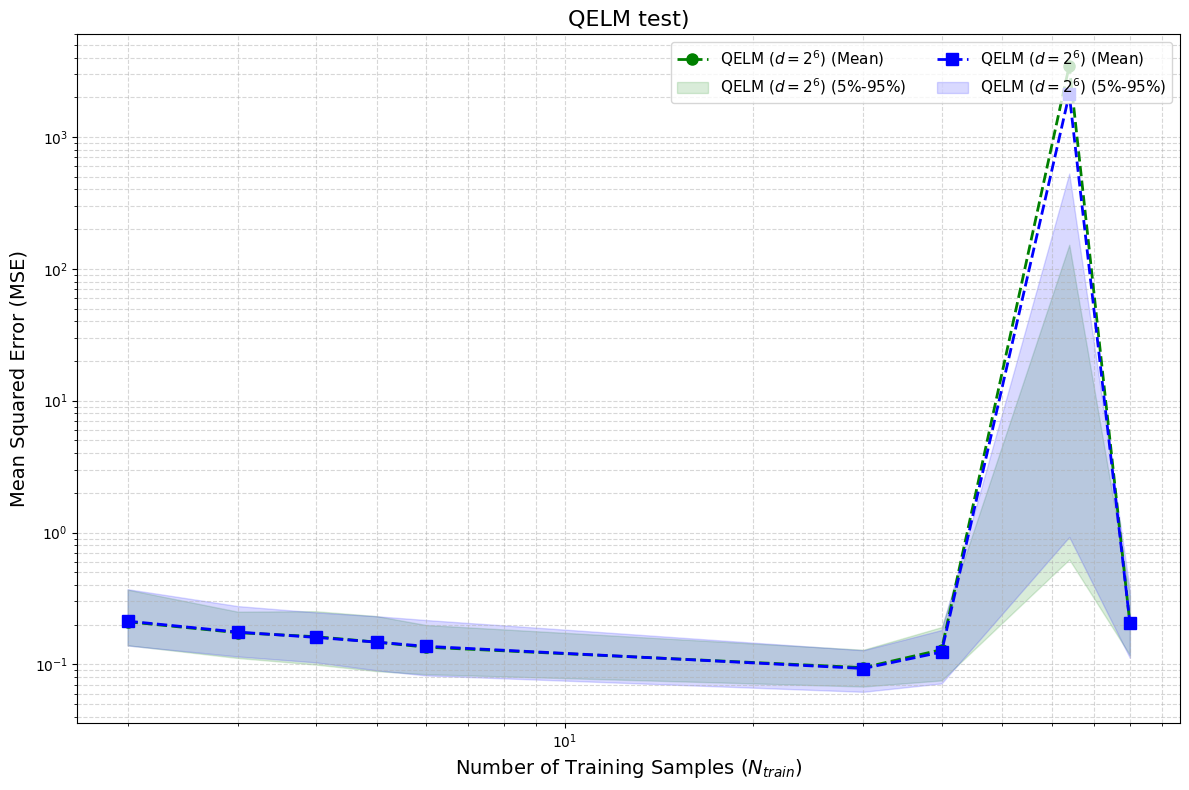

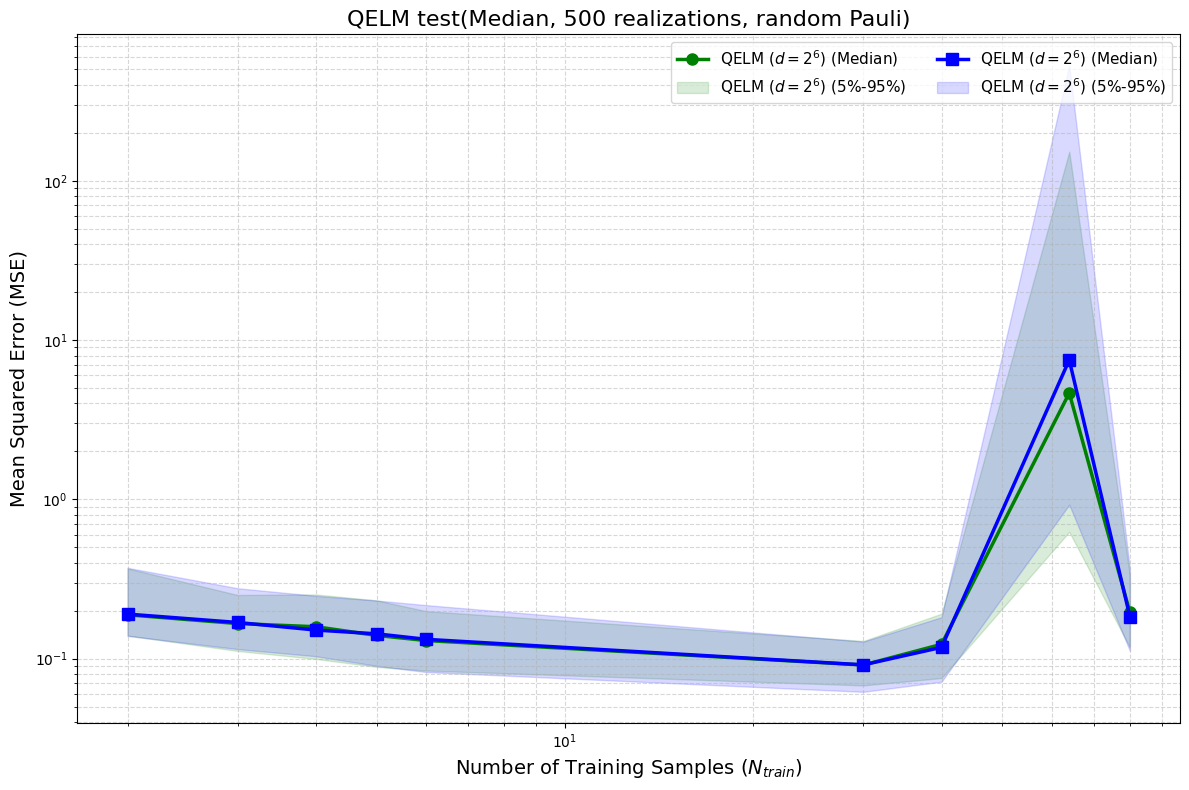

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt

filename = "qelm_test.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract the N_train values present in the file and sort them numerically
# (We convert them back from strings to integers)
N_train_list = sorted([int(k) for k in data['QELM_1'].keys()])
N_arr = np.array(N_train_list)

# Storage dictionaries for final plotting
results_mean = {'QELM_1': [], 'QELM_2': []}
results_median = {'QELM_1': [], 'QELM_2': []}
quantiles_5 = {'QELM_1': [], 'QELM_2': []}
quantiles_95 = {'QELM_1': [], 'QELM_2': []}

# 2. Compute statistics
#print("\n--- Final Results ---")
for N_train in N_train_list:
    str_N = str(N_train) # JSON keys are strings
    for model in ['QELM_1', 'QELM_2']:
        mse_array = np.array(data[model][str_N])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))
        
#    print(f"N = {N_train:<4d} | QELM: {results_mean['QELM'][-1]:.4f} | K-LE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW: {results_mean['Kernel_SWAP'][-1]:.4f}")


# ==========================================
# 3. Plotting Setup
# ==========================================
colors = {'QELM_1': 'green', 'QELM_2': 'blue'}
labels = {'QELM_1': 'QELM ($d=2^6$)', 'QELM_2': 'QELM ($d=2^6$)'}
markers = {'QELM_1': 'o', 'QELM_2': 's'}


# ==========================================
# IMAGE 1: MEAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Mean
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Mean plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM test)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()


# ==========================================
# IMAGE 2: MEDIAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_median.keys():
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Median plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM test(Median, 500 realizations, random Pauli)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()

# Show both figures at the same time
plt.show()

In [17]:
import numpy as np
import time


# --- Helper functions to generate random quantum data for testing ---
def generate_random_density_matrices(N, dim):
    """Generates N random valid density matrices of dimension dim."""
    A = np.random.randn(N, dim, dim) + 1j * np.random.randn(N, dim, dim)
    A = (A + A.conj().transpose(0, 2, 1)) / 2
    rho = A @ A.conj().transpose(0, 2, 1)
    traces = np.trace(rho, axis1=1, axis2=2)[:, np.newaxis, np.newaxis]
    return rho / traces

def generate_dummy_qelm_params(d_in=2, d_out=4, num_povm=6):
    """Generates a random isometry and a valid POVM."""
    # Isometry
    X = (np.random.randn(d_out, d_out) + 1j * np.random.randn(d_out, d_out)) / np.sqrt(2)
    Q, _ = np.linalg.qr(X)
    isometry = Q[:, :d_in]
    
    # POVM (for subsystem kept, let's assume bipartite is 2x2, so dim=2)
    dim_kept = 2
    elements = []
    total_sum = np.zeros((dim_kept, dim_kept), dtype=complex)
    for _ in range(num_povm):
        A = np.random.randn(dim_kept, dim_kept) + 1j * np.random.randn(dim_kept, dim_kept)
        M = A @ A.conj().T
        elements.append(M)
        total_sum += M
    
    from scipy.linalg import sqrtm, inv
    normalization = inv(sqrtm(total_sum))
    povm = [normalization @ E @ normalization for E in elements]
    
    return isometry, povm

# --- BENCHMARK SCRIPT ---
def run_benchmark():
    print("=== Starting QELM Version Benchmark ===\n")
    
    # 1. Setup dimensions and data
    N_train = 200
    N_test = 50
    d_in = 2
    bipartite_dims = (2, 2)  # 2x2 = 4 (d_out)
    num_povm = 6
    
    print(f"Generating {N_train} train and {N_test} test samples...")
    rho_train = generate_random_density_matrices(N_train, d_in)
    rho_test = generate_random_density_matrices(N_test, d_in)
    
    # Dummy labels (e.g., expectation values)
    y_train = np.random.randn(N_train)
    y_test = np.random.randn(N_test)
    
    isometry, povm = generate_dummy_qelm_params(d_in=d_in, d_out=4, num_povm=num_povm)
    
    # Initialize the QELM model (Exact limit: num_shots=None to compare exact math)
    model = myQML.QuantumExtremeLearningMachine(
        isometry=isometry,
        povm=povm,
        bipartite_dims=bipartite_dims,
        keep_subsystem=1,
        num_shots=None 
    )

    # 2. Test Features Extraction
    print("\n--- Testing Features ---")
    t0 = time.time()
    P1 = model.get_features_vec(rho_train)
    t1 = time.time()
    
    t2 = time.time()
    P2 = model.get_features_vec_2(rho_train)
    t3 = time.time()
    
    print(f"P1 (vec)   shape: {P1.shape} | Time: {t1-t0:.4f}s")
    print(f"P2 (vec_2) shape: {P2.shape} | Time: {t3-t2:.4f}s")
    
    # P1 should be (N, M). P2 should be (M, N). Therefore P1.T should equal P2.
    np.testing.assert_allclose(P1.T, P2, atol=1e-10, 
                               err_msg="Features do not match!")
    print("✅ Features match perfectly (P1.T == P2).")

    # 3. Test Training (Fit)
    print("\n--- Testing Fit (Weights) ---")
    model.fit_vec(rho_train, y_train)
    W1 = model.W.copy()
    
    model.fit_vec_2(rho_train, y_train)
    W2 = model.W.copy()
    
    print(f"W1 (vec)   shape: {W1.shape}")
    print(f"W2 (vec_2) shape: {W2.shape}")
    
    # Because both methods solve for the same physical weights mapping POVMs to labels, 
    # the resulting weights should be exactly identical!
    np.testing.assert_allclose(W1, W2, atol=1e-10, 
                               err_msg="Trained weights do not match!")
    print("✅ Weights match perfectly (W1 == W2).")

    # 4. Test Predictions
    print("\n--- Testing Predictions ---")
    # Restore W1 to test predict_vec (since fit_vec_2 overwrote self.W)
    model.W = W1 
    y_pred_1 = model.predict_vec(rho_test)
    
    model.W = W2
    y_pred_2 = model.predict_vec_2(rho_test)
    
    print(f"Pred 1 shape: {y_pred_1.shape}")
    print(f"Pred 2 shape: {y_pred_2.shape}")
    
    np.testing.assert_allclose(y_pred_1, y_pred_2, atol=1e-10, 
                               err_msg="Predictions do not match!")
    print("✅ Predictions match perfectly (y_pred_1 == y_pred_2).")
    
    print("\n=== All Benchmarks Passed Successfully! ===")

if __name__ == "__main__":
    run_benchmark()

=== Starting QELM Version Benchmark ===

Generating 200 train and 50 test samples...

--- Testing Features ---
P1 (vec)   shape: (200, 6) | Time: 0.0006s
P2 (vec_2) shape: (6, 200) | Time: 0.0009s
✅ Features match perfectly (P1.T == P2).

--- Testing Fit (Weights) ---
W1 (vec)   shape: (6,)
W2 (vec_2) shape: (6,)
✅ Weights match perfectly (W1 == W2).

--- Testing Predictions ---
Pred 1 shape: (50,)
Pred 2 shape: (50,)
✅ Predictions match perfectly (y_pred_1 == y_pred_2).

=== All Benchmarks Passed Successfully! ===
